In [ ]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
import requests
from bs4 import BeautifulSoup
import time
import os

# SELENIUM으로 열기
url = "https://www.yeogi.com/domestic-accommodations?keyword=%EA%B2%BD%EC%A3%BC&personal=2&checkIn=2026-10-08&checkOut=2026-10-09&typoCorrect=true&nonAffiliated=true&category=2&sortType=RECOMMEND"
options = Options()
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option("useAutomationExtension", False)
options.add_argument("--disable-blink-features=AutomationControlled")
browser = webdriver.Chrome(options=options)
browser.maximize_window() # 화면 최대창 확대
browser.get(url)

# time.sleep(2)
# pre_h = browser.execute_script("return document.body.scrollHeight")
# print("최초 높이: ", pre_h)
# while True:
#     browser.execute_script("window.scroll(0, document.body.scrollHeight)")
#     time.sleep(2)

#     next_h = browser.execute_script("return document.body.scrollHeight")
#     print("변경된 높이: ", next_h)

#     if pre_h == next_h:  break
#     else : pre_h = next_h

# print("더 스크롤할 내용 없음")
# time.sleep(2)

# # SELENIUM으로 열기2
# soup = BeautifulSoup(browser.page_source,'lxml')
# with open('file0/yeo2.html','w',encoding='utf-8') as f:
#     f.write(soup.prettify())

최초 높이:  7155
변경된 높이:  12819
변경된 높이:  17588
변경된 높이:  17588
더 스크롤할 내용 없음


In [3]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

In [7]:
import pandas as pd
import numpy as np

# 이름 평점 평가수 금액

In [ ]:
# data1 = []
# data1.append({
#     '숙소명' : '힐튼 경주',
#     '평점' : 9.4,
#     '평가수' : '10,361',
#     '금액' : '202,400'
# })

In [ ]:
# data1.append({
#     '숙소명' : '오소한옥스테이',
#     '평점' : 9.8,
#     '평가수' : '154',
#     '금액' : '325,000'
# })

In [14]:
# df = pd.DataFrame(data1)
# df


In [37]:
with open('file0/yeo2.html','r',encoding='utf-8') as f:
    soup = BeautifulSoup(f,'lxml')
# print(soup)

acc = soup.find("ul", {"class":"css-y5z6rw"})
lis = acc.find_all("li", {"class":"gc-thumbnail-type-seller-card-wrapper css-13wylk3"})

print(f"총 숙소 개수: {len(lis)}개")

hotel1 = []
# i = 0
# count01 = 0
# for i, li in enumerate(lis):
#     # print(f"{i+1}.")
#     try :
#         titles = li.find("h3", {"class": "gc-thumbnail-type-seller-card-title css-1gsfgy5"})
#         titles1 = titles.get_text(strip=True)
#         stars = li.find("span", {"class": "css-ry30z7"}).get_text(strip=True)
#         stars1 = float(stars)
#         reviews = li.find("span", {"class": "css-144z61f"}).get_text(strip=True)[:-4].replace(",","")
#         reviews1 = int(reviews)
#         prcs = li.find("span", {"class": "css-1llao6q"}).get_text(strip=True).replace(",","")
#         prcs1 = int(prcs) 
#         h_imgs = li.find("img")["src"]
#         hotel1.append({
#             '숙소명': titles1,
#             '별점': stars1,
#             '리뷰수': reviews1,
#             '금액': prcs1
#         })
#         # print(f"숙소명: {titles1} / 별점: {stars1} / 리뷰수: {reviews1} / 금액: {prcs1}")
#     except Exception as e:
#         pass

i = 0
count01 = 0
for i, li in enumerate(lis):
    # 1. 각 필드를 안전하게 가져오기 위한 변수 초기화 (기본값 None)
    titles1 = None
    stars1 = None
    reviews1 = None
    prcs1 = None
    h_imgs = None

    try:
        # 숙소명
        titles = li.find(
        "h3", {"class": "gc-thumbnail-type-seller-card-title css-1gsfgy5"}
        )
        if titles:
            titles1 = titles.get_text(strip=True)

        # 별점
        stars_tag = li.find("span", {"class": "css-ry30z7"})
        if stars_tag:
            stars_text = stars_tag.get_text(strip=True)
            stars1 = float(stars_text) if stars_text else None

        # 리뷰수
        reviews_tag = li.find("span", {"class": "css-144z61f"})
        if reviews_tag:
            reviews_text = (
                reviews_tag.get_text(strip=True)[:-4].replace(",", "").strip()
            )
        reviews1 = int(reviews_text) if reviews_text else None

        # 금액
        prcs_tag = li.find("span", {"class": "css-1llao6q"})
        if prcs_tag:
            prcs_text = prcs_tag.get_text(strip=True).replace(",", "").strip()
            prcs1 = int(prcs_text) if prcs_text else None

    except Exception as e:
    # 예상치 못한 시스템적 에러만 간단히 확인하고 싶을 때 사용
    # print(f"{i+1}번째 항목 처리 중 예외 발생: {e}")
        pass

    # 2. 에러 여부와 상관없이, 수집된 데이터를 무조건 리스트에 추가합니다.
    # (값이 없으면 DataFrame에 NaN으로 자동 변환됩니다.)
    hotel1.append(
        {"숙소명": titles1, "별점": stars1, "리뷰수": reviews1, "금액": prcs1}
    )
df = pd.DataFrame(hotel1)
df = df.sort_values(['금액'], ascending=False)
df2 = df.head(10)


총 숙소 개수: 59개


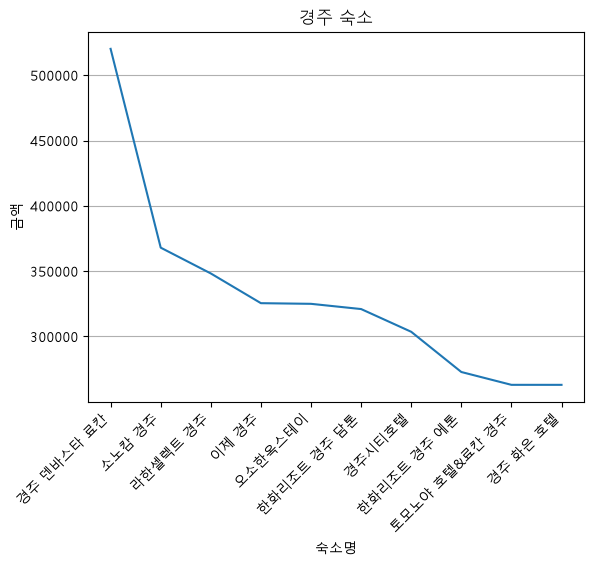

In [41]:
x = df2['숙소명']
y = df2['금액']
plt.plot(x,y)
plt.title('경주 숙소')
plt.xlabel('숙소명')
plt.ylabel('금액')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')


plt.show()